<a href="https://colab.research.google.com/github/ValentinaQuinteroC/Challenge_TELECOMX2/blob/main/challenge_telecomx2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Telecom X – Parte 2: Predicción de Cancelación (Churn)

🧠 Objetivos del Desafío

Preparar los datos para el modelado (tratamiento, codificación, normalización).

Realizar análisis de correlación y selección de variables.

Entrenar dos o más modelos de clasificación.

Evaluar el rendimiento de los modelos con métricas.

Interpretar los resultados, incluyendo la importancia de las variables.

Crear una conclusión estratégica señalando los principales factores que influyen en la cancelación.

##PREPARACION DE DATOS

###EXTRACCION DE ARCHIVO TRATADO E IMPORTANTO BIBLIOTECAS

In [122]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [123]:
datos_limpios = pd.read_csv('datos_tratados.csv')

In [124]:
datos_limpios.head()

,Identificacion del usuario,Abandonó,Género,Adulto mayor,Pareja,Dependientes,Meses de contrato,Servicio telefónico,Lineas múltiples,Servicio de internet,...,Protección del dispositivo,Soporte técnico,StreamingTV,Películas de Streaming,Contrato,Factura electrónica,Método de pago,Cuentas mensuales,Cuenta total,Cuentas diarias
0,0002-ORFBO,0.0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0.0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1.0,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1.0,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1.0,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


### BORRANDO COLUMNAS INNECESARIAS

In [125]:
datos_limpios = datos_limpios.drop(['Identificacion del usuario', 'Género'], axis=1)

In [126]:
datos_limpios.columns

Index(['Abandonó', 'Adulto mayor', 'Pareja', 'Dependientes',
       'Meses de contrato', 'Servicio telefónico', 'Lineas múltiples',
       'Servicio de internet', 'Seguridad en línea', 'Respaldo en línea',
       'Protección del dispositivo', 'Soporte técnico', 'StreamingTV',
       'Películas de Streaming', 'Contrato', 'Factura electrónica',
       'Método de pago', 'Cuentas mensuales', 'Cuenta total',
       'Cuentas diarias'],
      dtype='object')

###ENCODIG

In [127]:
# 1. Definir las columnas que contienen texto (categóricas)
columnas_a_transformar = [
      'Servicio de internet',
    'Contrato',
    'Método de pago'
]

# 2. Aplicar One-Hot Encoding
df_final = pd.get_dummies(datos_limpios, columns=columnas_a_transformar, drop_first=True)

# 3. Verificamos los nuevos nombres de las columnas
print("Nuevas columnas generadas:")
print(df_final.columns.tolist())

#Contrato_One year: (1 si es anual, 0 si no), Contrato_Two year: (1 si es a dos años, 0 si no), Si ambas son 0,
#el modelo entiende por descarte que es Month-to-month.

Nuevas columnas generadas:
['Abandonó', 'Adulto mayor', 'Pareja', 'Dependientes', 'Meses de contrato', 'Servicio telefónico', 'Lineas múltiples', 'Seguridad en línea', 'Respaldo en línea', 'Protección del dispositivo', 'Soporte técnico', 'StreamingTV', 'Películas de Streaming', 'Factura electrónica', 'Cuentas mensuales', 'Cuenta total', 'Cuentas diarias', 'Servicio de internet_Fiber optic', 'Servicio de internet_No', 'Contrato_One year', 'Contrato_Two year', 'Método de pago_Credit card (automatic)', 'Método de pago_Electronic check', 'Método de pago_Mailed check']


In [128]:
df_final.head()

,Abandonó,Adulto mayor,Pareja,Dependientes,Meses de contrato,Servicio telefónico,Lineas múltiples,Seguridad en línea,Respaldo en línea,Protección del dispositivo,...,Cuentas mensuales,Cuenta total,Cuentas diarias,Servicio de internet_Fiber optic,Servicio de internet_No,Contrato_One year,Contrato_Two year,Método de pago_Credit card (automatic),Método de pago_Electronic check,Método de pago_Mailed check
0,0.0,0,1,1,9,1,0,0,1,0,...,65.6,593.30,2.186667,False,False,True,False,False,False,True
1,0.0,0,0,0,9,1,1,0,0,0,...,59.9,542.40,1.996667,False,False,False,False,False,False,True
2,1.0,0,0,0,4,1,0,0,0,1,...,73.9,280.85,2.463333,True,False,False,False,False,True,False
3,1.0,1,1,0,13,1,0,0,1,1,...,98.0,1237.85,3.266667,True,False,False,False,False,True,False
4,1.0,1,1,0,3,1,0,0,0,0,...,83.9,267.40,2.796667,True,False,False,False,False,False,True


In [129]:
# 1. Ver cuántos nulos hay
nulos_target = df_final['Abandonó'].isnull().sum()
print(f"Valores nulos encontrados en 'Abandonó': {nulos_target}")

# 2. Eliminar filas donde 'Abandonó' es NaN
df_final = df_final.dropna(subset=['Abandonó'])
df_final = df_final.fillna(df_final.median())

Valores nulos encontrados en 'Abandonó': 224


### VERIFICACIÓN DE LA PROPORCIÓN DE CANCELACIÓN (CHURN)

In [130]:
# 1. Calculamos el conteo usando datos_limpios
conteo_clases = datos_limpios['Abandonó'].value_counts()

# 2. Calculamos la proporción porcentual
proporcion = datos_limpios['Abandonó'].value_counts(normalize=True) * 100

print("--- Análisis de Balance de Clases ---")
print(f"Clientes que permanecieron (0): {conteo_clases[0]} ({proporcion[0]:.2f}%)")
print(f"Clientes que cancelaron (1):    {conteo_clases[1]} ({proporcion[1]:.2f}%)")

# 3. Interpretación rápida
if proporcion[1] < 25:
    print("\nEstado: Desbalanceado. La clase 'Abandonó' es minoritaria.")
else:
    print("\nEstado: Relativamente balanceado.")

--- Análisis de Balance de Clases ---
Clientes que permanecieron (0): 5174 (73.46%)
Clientes que cancelaron (1):    1869 (26.54%)

Estado: Relativamente balanceado.


### NORMALIZACIÓN O ESTANDARIZACIÓN

In [131]:
#Seleccionamos solo las columnas numéricas continuas
cols_a_escalar = ['Meses de contrato', 'Cuentas mensuales', 'Cuenta total', 'Cuentas diarias']

scaler = StandardScaler()
df_escalado = df_final.copy()
df_escalado[cols_a_escalar] = scaler.fit_transform(df_final[cols_a_escalar])

print("Datos escalados (primeras filas):")
print(df_escalado[cols_a_escalar].head())

Datos escalados (primeras filas):
   Meses de contrato  Cuentas mensuales  Cuenta total  Cuentas diarias
0          -0.951682           0.027862     -0.745490         0.027862
1          -0.951682          -0.161583     -0.767961        -0.161583
2          -1.155283           0.303720     -0.883431         0.303720
3          -0.788800           1.104706     -0.460934         1.104706
4          -1.196004           0.636080     -0.889368         0.636080


## CORRELACION Y SELECCION DE VARIABLES

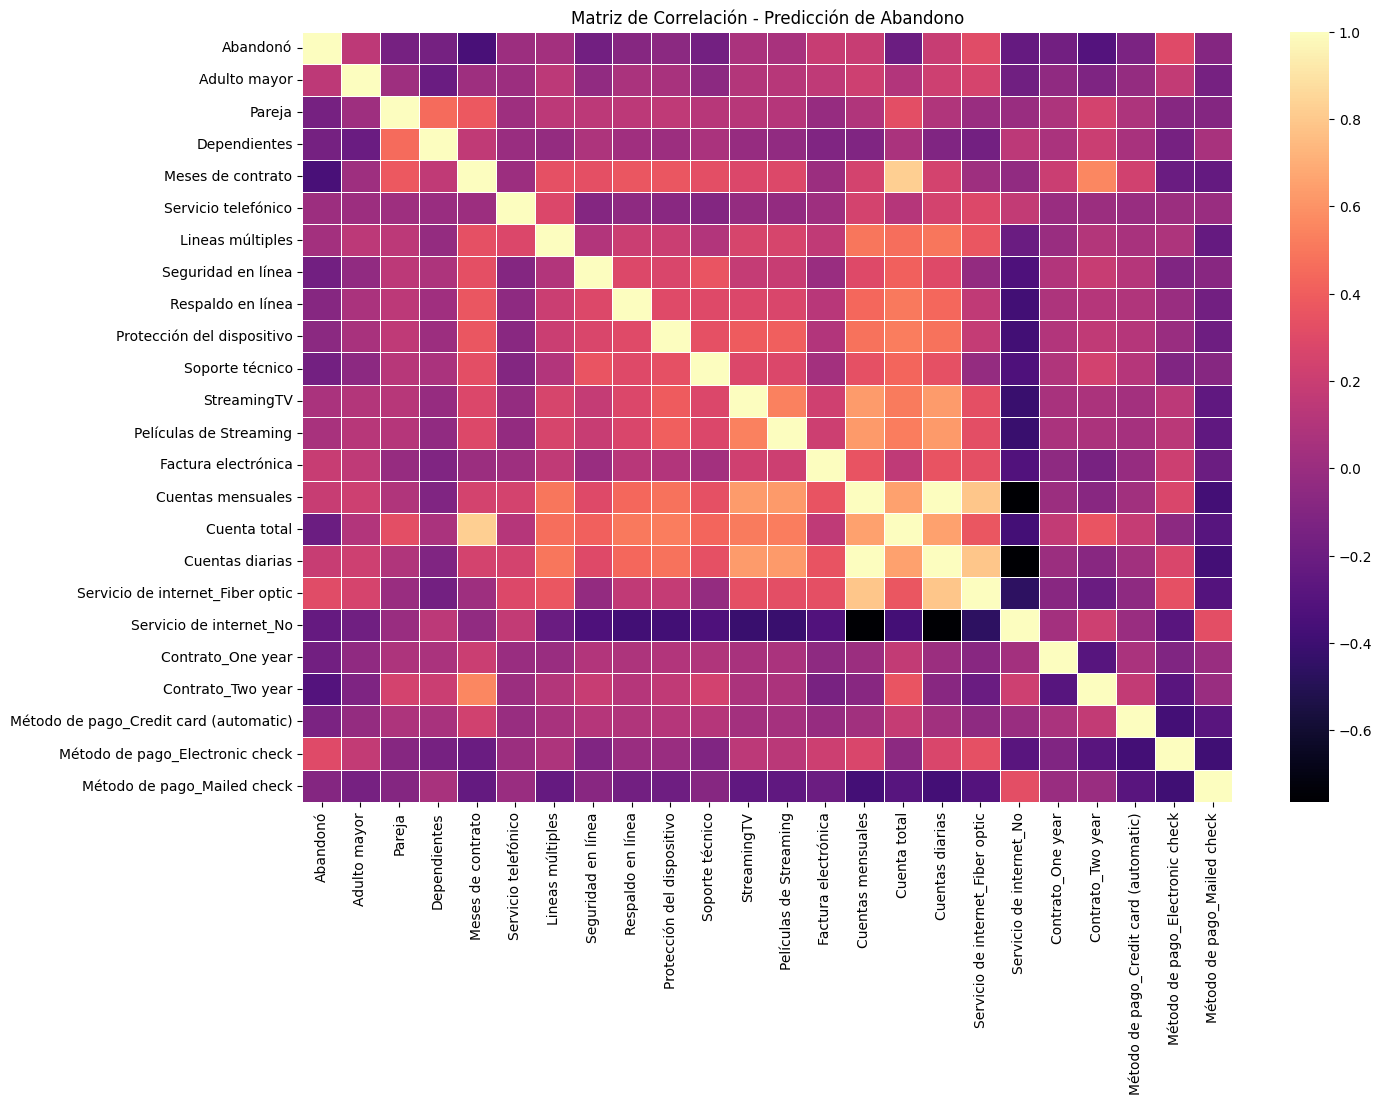

In [132]:
#Calculamos la matriz de correlación
corr_matrix = df_final.corr()

plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix,
            annot=False,          # Cambia a True si quieres ver los números exactos
            cmap='magma',      # Azul para negativo, rojo para positivo
            linewidths=0.5,
            fmt=".2f")

plt.title('Matriz de Correlación - Predicción de Abandono')
plt.show()

In [133]:
# Ver solo la correlación respecto a 'Abandonó' ordenada de mayor a menor
correlaciones_target = df_final.corr()['Abandonó'].sort_values(ascending=False)
print(correlaciones_target)

Abandonó                                  1.000000
Servicio de internet_Fiber optic          0.308020
Método de pago_Electronic check           0.301919
Cuentas mensuales                         0.193356
Cuentas diarias                           0.193356
Factura electrónica                       0.191825
Adulto mayor                              0.150889
StreamingTV                               0.063228
Películas de Streaming                    0.061382
Lineas múltiples                          0.040102
Servicio telefónico                       0.011942
Protección del dispositivo               -0.066160
Respaldo en línea                        -0.082255
Método de pago_Mailed check              -0.091683
Método de pago_Credit card (automatic)   -0.134302
Pareja                                   -0.150448
Dependientes                             -0.164221
Soporte técnico                          -0.164674
Seguridad en línea                       -0.171226
Contrato_One year              

### ANALISIS DIRIGIDO

### TIEMPO DE CONTRATO (MESES) VS CANCELACION

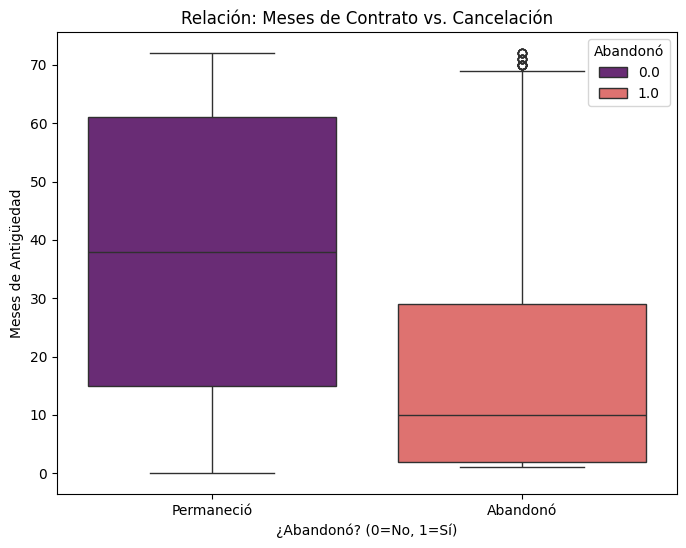

In [134]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Abandonó', y='Meses de contrato', data=df_final, palette='magma', hue = 'Abandonó')

plt.title('Relación: Meses de Contrato vs. Cancelación')
plt.xlabel('¿Abandonó? (0=No, 1=Sí)')
plt.ylabel('Meses de Antigüedad')
plt.xticks([0, 1], ['Permaneció', 'Abandonó'])
plt.show()

### GASTO TOTAL VS CANCELACION

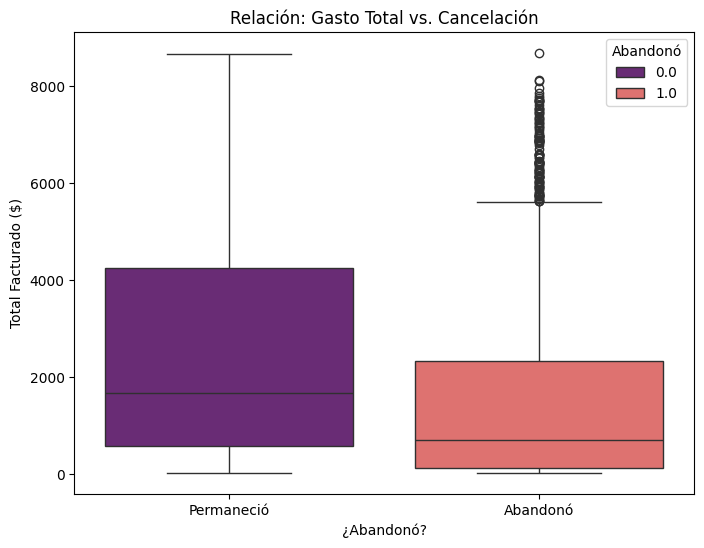

In [135]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Abandonó', y='Cuenta total', data=df_final, palette='magma', hue ='Abandonó')

plt.title('Relación: Gasto Total vs. Cancelación')
plt.xlabel('¿Abandonó?')
plt.ylabel('Total Facturado ($)')
plt.xticks([0, 1], ['Permaneció', 'Abandonó'])
plt.show()

## MODELADO PREDICTIVO

In [136]:
# 1. Separar características (X) y etiqueta (y)
X = df_final.drop(columns=['Abandonó'])
y = df_final['Abandonó']

# 2. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Registros para entrenamiento: {X_train.shape[0]}")
print(f"Registros para prueba: {X_test.shape[0]}")

Registros para entrenamiento: 5634
Registros para prueba: 1409


### CREACION DE MODELOS

#### MODELO 1: REGRESIÓN LOGÍSTICA CON NORMALIZACION

In [137]:
# Creamos un pipeline que escala los datos y luego aplica el modelo
modelo_logistico = make_pipeline(StandardScaler(), LogisticRegression(random_state=42))

# Entrenamos
modelo_logistico.fit(X_train, y_train)

# Predicciones
y_pred_log = modelo_logistico.predict(X_test)

print("--- Evaluación: Regresión Logística ---")
print(classification_report(y_test, y_pred_log))

--- Evaluación: Regresión Logística ---
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.87      1035
         1.0       0.64      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



#### MODELO 2: RANDOM FOREST

In [138]:
# Creamos el modelo (los árboles son robustos a la escala)
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Entrenamos
modelo_rf.fit(X_train, y_train)

# Predicciones
y_pred_rf = modelo_rf.predict(X_test)

print("--- Evaluación: Random Forest ---")
print(classification_report(y_test, y_pred_rf))

--- Evaluación: Random Forest ---
              precision    recall  f1-score   support

         0.0       0.83      0.90      0.86      1035
         1.0       0.63      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



### EVALUACION DE LOS MODELOS


MÉTRICAS: REGRESIÓN LOGÍSTICA
Exactitud (Accuracy): 0.7956
Precisión (Clase 1):  0.6387
Recall (Clase 1):     0.5294
F1-score (Clase 1):   0.5789

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.87      1035
         1.0       0.64      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409


MÉTRICAS: RANDOM FOREST
Exactitud (Accuracy): 0.7871
Precisión (Clase 1):  0.6321
Recall (Clase 1):     0.4733
F1-score (Clase 1):   0.5413

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.83      0.90      0.86      1035
         1.0       0.63      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



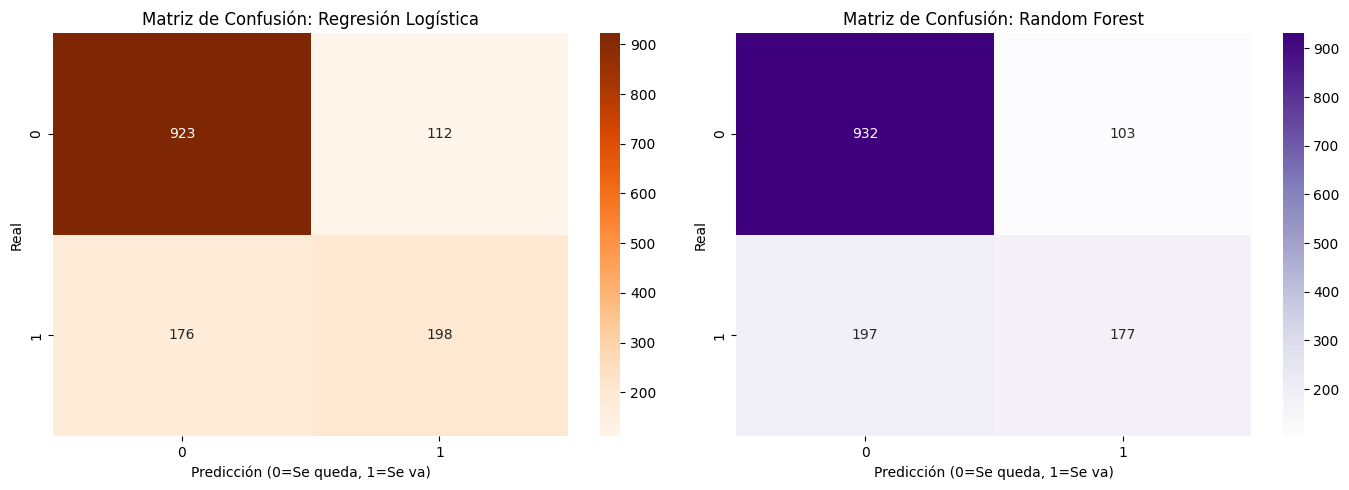

In [142]:
# Función para calcular y mostrar métricas
def evaluar_modelo(nombre_modelo, y_real, y_pred):
    print(f"\n{'='*30}")
    print(f"MÉTRICAS: {nombre_modelo}")
    print(f"{'='*30}")

    # 1. Cálculo de métricas individuales
    accuracy = accuracy_score(y_real, y_pred)
    precision = precision_score(y_real, y_pred)
    recall = recall_score(y_real, y_pred)
    f1 = f1_score(y_real, y_pred)

    print(f"Exactitud (Accuracy): {accuracy:.4f}")
    print(f"Precisión (Clase 1):  {precision:.4f}")
    print(f"Recall (Clase 1):     {recall:.4f}")
    print(f"F1-score (Clase 1):   {f1:.4f}")

    # 2. Reporte detallado (incluye precision/recall de la clase 0)
    print("\nReporte de Clasificación:")
    print(classification_report(y_real, y_pred))

    return confusion_matrix(y_real, y_pred)

# --- EJECUCIÓN ---

# Evaluación Regresión Logística
cm_log = evaluar_modelo("REGRESIÓN LOGÍSTICA", y_test, y_pred_log)

# Evaluación Random Forest
cm_rf = evaluar_modelo("RANDOM FOREST", y_test, y_pred_rf)

# --- VISUALIZACIÓN DE MATRICES DE CONFUSIÓN ---

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Matriz Logística
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Oranges', ax=ax[0])
ax[0].set_title('Matriz de Confusión: Regresión Logística')
ax[0].set_xlabel('Predicción (0=Se queda, 1=Se va)')
ax[0].set_ylabel('Real')

# Matriz Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', ax=ax[1])
ax[1].set_title('Matriz de Confusión: Random Forest')
ax[1].set_xlabel('Predicción (0=Se queda, 1=Se va)')
ax[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

In [144]:
# Comparar Exactitud Entrenamiento vs Prueba para Random Forest
train_acc = modelo_rf.score(X_train, y_train)
test_acc = modelo_rf.score(X_test, y_test)

print(f"\nRF - Accuracy Entrenamiento: {train_acc:.4f}")
print(f"RF - Accuracy Prueba:        {test_acc:.4f}")

if train_acc - test_acc > 0.10:
    print("ALERTA: Posible Overfitting detectado.")


RF - Accuracy Entrenamiento: 0.9972
RF - Accuracy Prueba:        0.7871
ALERTA: Posible Overfitting detectado.


## INTERPRETACION Y CONCLUSIONES

Después de analizar a fondo la base de datos de nuestros clientes y poner a trabajar  los modelos de predicción, estas son las conclusiones principales:

1. ¿Qué es lo que más lleva al cliente a irse?

El "Contrato Mes a Mes" es el culpable #1: No tener un compromiso a largo plazo es como dejar la puerta abierta. Los clientes que pagan mes a mes son, por mucho, los que más fácil cancelan los servicios.

La antigüedad es nuestro escudo: Confirmamos que mientras más meses lleva un cliente con nosotros, menos probable es que se vaya. El "peligro" real está en los clientes nuevos.

2. ¿En qué se fijan más los clientes antes de cancelar los servicios?

Los datos muestran que el monto de la factura mensual y el total que han pagado son las pistas más importantes. Básicamente, el precio es el factor que mejor nos ayuda a distinguir quién se queda y quién se va. Si el precio no les favorece, es mas factible que busquen otras opciones con la competencia.

Probamos dos formas distintas de predecir resultados y ambas coinciden en un resultado un 79% de las veces. Esto significa que de cada 10 clientes que analizamos, en casi 8 acertamos si se van a quedar o no, por lo que se recomienda:

1. Tenemos que enfocarnos en los clientes que llevan menos de 6 meses. Si logramos que pasen esa barrera, es mucho más probable que se vuelvan leales, por lo que se les puede incentivar mediante promociones o beneficios.

2. Debemos revisar si nuestros planes son competitivos o si podemos ofrecer descuentos a quienes acepten pasar de un plan mensual a uno anual, ya que los precios son nuestro pundo debil mas grande

